# PLACES Health Data - Modeling (Modeler Notebook)

**Group 3:** Salam Odeh, Qossay Shtaiwi, Ali Odah

**Dataset:** PLACES: Local Data for Better Health, Census Tract Data (2024 release) — CDC / U.S. Department of Health & Human Services

**Role:** Modeler (Salam Odeh)

**Input:** `places_wide_clean.csv`, produced by the Data Wrangler notebook (`01_data_cleaning.ipynb`)

**Target variable:** `Diabetes` (% of adults with diagnosed diabetes, crude prevalence) — a regression task.

**What we're building on from the Analyzer's EDA (`02_eda.ipynb`):**
- Strongest predictors: `Mobility Disability`, `Stroke`, `Self-care Disability`, `Frequent Physical Distress`, `Physical Inactivity`, `High Blood Pressure` (all r > 0.8 with Diabetes)
- Several top predictors are highly correlated *with each other* (multicollinearity) — the EDA notebook recommended tree-based models as the primary approach for this reason, with linear regression kept only as an interpretability baseline
- The `Health Insurance` column actually measures the *lack* of insurance — kept as-is here since the model doesn't care about the name, but worth remembering when discussing feature importance

**Tasks:**
1. Load the clean data and prepare train/test sets
2. Build a Linear Regression baseline
3. Build default Random Forest and Gradient Boosting models
4. Compare all three baselines
5. Tune the best-performing model with `GridSearchCV`
6. Evaluate the tuned model against the untuned baseline
7. Examine feature importances and connect them back to the EDA findings
8. Discuss limitations of the modeling approach


## 1. Imports and Custom Evaluation Function

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', 100)

In [3]:
# Custom evaluation function (matches the style of evaluate_classification from Topic 7/8)
def evaluate_regression(model, X_train, y_train, X_test, y_test, label='', output_frame=False):
    """Complete evaluation for regression: R2, RMSE, MAE, overfitting check."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    test_mae = mean_absolute_error(y_test, y_test_pred)

    header = "=" * 55
    print(header)
    if label:
        print(f"  Model: {label}")
        print(header)
    print(f"  Training R2   : {train_r2:.4f}")
    print(f"  Test R2       : {test_r2:.4f}")
    print(f"  Test RMSE     : {test_rmse:.4f}  (percentage points)")
    print(f"  Test MAE      : {test_mae:.4f}  (percentage points)")
    print()
    gap = train_r2 - test_r2
    if gap > 0.05:
        print(f"  [!] Possible overfitting: train-test R2 gap = {gap:.4f}")
    else:
        print(f"  [OK] Train-test R2 gap = {gap:.4f}")

    if output_frame:
        return pd.DataFrame({
            'Model': [label if label else 'Model'],
            'Train R2': [round(train_r2, 4)],
            'Test R2': [round(test_r2, 4)],
            'Test RMSE': [round(test_rmse, 4)],
            'Test MAE': [round(test_mae, 4)],
        }).set_index('Model')

## 2. Load the Data and Prepare Train/Test Sets

**Note on file path:** update `fpath` below to wherever `places_wide_clean.csv` was saved.

We drop the reference columns (state, county, population, coordinates, tract ID) from the feature set — they describe *where* a tract is, not a measurable health behavior or outcome, so they aren't useful (or fair) inputs for a health-prediction model.

In [4]:
fpath = '../Data/places_wide_clean.csv'

df = pd.read_csv(fpath, dtype={'LocationName': str, 'CountyFIPS': str})
print(df.shape)
df.head()

(78784, 48)


,LocationName,StateAbbr,StateDesc,CountyName,CountyFIPS,TotalPopulation,TotalPop18plus,Geolocation,All Teeth Lost,Annual Checkup,Any Disability,Arthritis,Binge Drinking,COPD,Cancer (non-skin) or Melanoma,Cholesterol Screening,Cognitive Disability,Colorectal Cancer Screening,Coronary Heart Disease,Current Asthma,Current Cigarette Smoking,Dental Visit,Depression,Diabetes,Food Insecurity,Food Stamps,Frequent Mental Distress,Frequent Physical Distress,General Health,Health Insurance,Hearing Disability,High Blood Pressure,High Blood Pressure Medication,High Cholesterol,Housing Insecurity,Independent Living Disability,Lack of Social/Emotional Support,Loneliness,Mammography,Mobility Disability,Obesity,Physical Inactivity,Self-care Disability,Short Sleep Duration,Stroke,Transportation Barriers,Utility Services Threat,Vision Disability
0,01001020100,AL,Alabama,Autauga,01001,1775,1370,POINT (-86.4915648 32.4819731),13.4,80.1,35.7,30.6,14.8,8.2,8.5,85.5,16.8,65.0,7.2,10.2,15.6,57.3,26.6,13.3,17.0,11.6,17.9,14.7,22.5,9.7,8.6,41.4,77.8,41.9,12.3,9.6,23.5,33.0,78.0,16.3,39.4,27.8,4.4,37.9,3.8,8.9,8.1,5.5
1,01001020200,AL,Alabama,Autauga,01001,2055,1584,POINT (-86.4724678 32.475758),15.9,81.8,36.9,29.5,12.9,7.6,6.3,85.6,17.3,68.1,6.5,10.8,16.7,56.1,23.3,15.8,24.8,18.4,18.5,14.4,25.1,10.6,6.7,45.9,78.3,39.7,18.5,10.4,29.1,36.1,79.2,17.8,44.7,32.0,5.0,42.6,4.4,12.0,12.5,6.6
2,01001020300,AL,Alabama,Autauga,01001,3216,2485,POINT (-86.4597033 32.4740243),14.7,80.6,37.7,31.5,13.9,8.5,8.5,85.5,17.6,67.4,7.3,10.7,16.1,57.7,26.3,13.9,19.1,13.1,18.6,15.1,23.7,10.6,8.6,42.9,78.4,41.8,14.1,10.3,25.9,35.1,75.5,17.6,40.3,29.9,4.6,39.0,4.1,9.7,9.0,5.8
3,01001020400,AL,Alabama,Autauga,01001,4246,3344,POINT (-86.4448353 32.4710304),9.3,81.7,33.9,32.5,14.2,7.6,10.3,88.0,14.2,71.5,7.5,9.6,12.9,61.1,24.9,12.8,12.5,7.9,15.8,13.5,19.5,7.9,9.3,42.4,80.1,43.4,9.3,8.3,21.5,31.0,78.1,15.5,36.9,25.5,3.6,35.8,3.8,6.8,6.1,4.7
4,01001020501,AL,Alabama,Autauga,01001,4322,3369,POINT (-86.4225578 32.4478607),9.9,81.3,27.5,27.7,15.6,5.2,9.0,89.0,12.0,70.5,5.4,9.3,10.0,66.3,24.0,10.2,9.5,5.4,14.8,11.0,14.9,6.2,6.8,37.2,77.8,40.5,8.1,6.3,21.1,30.8,79.8,11.2,34.7,20.3,2.6,35.1,2.8,5.5,5.1,3.3


In [5]:
ref_cols = ['LocationName', 'StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS',
            'TotalPopulation', 'TotalPop18plus', 'Geolocation']

y = df['Diabetes']
X = df.drop(columns=ref_cols + ['Diabetes'])

print(f"Features: {X.shape[1]}")
print(f"Target: Diabetes (mean = {y.mean():.2f}%, std = {y.std():.2f})")

Features: 39
Target: Diabetes (mean = 12.44%, std = 4.02)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (59088, 39) | Test: (19696, 39)


## Task 1: Baseline — Linear Regression

We scale the features first, since Linear Regression coefficients are sensitive to the scale of each input. This gives us a simple, interpretable baseline to compare the more complex models against.

**Reminder from the EDA notebook:** several features here are highly correlated with each other, so we should treat the *individual coefficients* of this model cautiously — they can become unstable when inputs overlap this much. We're using this model mainly as a performance baseline, not for coefficient interpretation.

In [7]:
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())
lr_pipe.fit(X_train, y_train)

lr_results = evaluate_regression(
    lr_pipe, X_train, y_train, X_test, y_test,
    label='Linear Regression (Baseline)', output_frame=True
)
lr_results

  Model: Linear Regression (Baseline)
  Training R2   : 0.9844
  Test R2       : 0.9848
  Test RMSE     : 0.4940  (percentage points)
  Test MAE      : 0.3855  (percentage points)

  [OK] Train-test R2 gap = -0.0004


,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Linear Regression (Baseline),0.9844,0.9848,0.494,0.3855


## Task 2: Random Forest (Default)

Tree-based models don't need feature scaling, and — per the EDA notebook's recommendation — they handle the multicollinearity in this dataset more gracefully than linear regression.

In [8]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_results = evaluate_regression(
    rf, X_train, y_train, X_test, y_test,
    label='Random Forest (Default)', output_frame=True
)
rf_results

  Model: Random Forest (Default)
  Training R2   : 0.9979
  Test R2       : 0.9855
  Test RMSE     : 0.4830  (percentage points)
  Test MAE      : 0.3518  (percentage points)

  [OK] Train-test R2 gap = 0.0124


,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Random Forest (Default),0.9979,0.9855,0.483,0.3518


## Task 3: Gradient Boosting (Default)

In [9]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

gb_results = evaluate_regression(
    gb, X_train, y_train, X_test, y_test,
    label='Gradient Boosting (Default)', output_frame=True
)
gb_results

  Model: Gradient Boosting (Default)
  Training R2   : 0.9778
  Test R2       : 0.9770
  Test RMSE     : 0.6085  (percentage points)
  Test MAE      : 0.4665  (percentage points)

  [OK] Train-test R2 gap = 0.0008


,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Gradient Boosting (Default),0.9778,0.977,0.6085,0.4665


## Task 4: Compare the Three Baselines

In [10]:
baseline_comparison = pd.concat([lr_results, rf_results, gb_results])
print("=== Baseline Model Comparison ===")
baseline_comparison

=== Baseline Model Comparison ===


,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Linear Regression (Baseline),0.9844,0.9848,0.4940,0.3855
Random Forest (Default),0.9979,0.9855,0.4830,0.3518
Gradient Boosting (Default),0.9778,0.9770,0.6085,0.4665


**All three baselines perform extremely well** (test R² above 0.97), with **Random Forest performing best** (highest test R², lowest RMSE/MAE) and showing only a small train-test gap, meaning it isn't just memorizing the training data.

**Important context — why are these scores so high?** All 40 measures in this dataset (including our target, `Diabetes`) come from the *same* underlying small-area statistical model, built from the *same* national BRFSS survey and Census data (see the PLACES methodology note in our project brief). This means the measures are not independent, real-world-collected signals the way, say, weather and ice cream sales would be — they share a common statistical origin. **This inflates how "predictable" one measure looks from the others.** We should be upfront about this in the presentation: our model shows a very strong *statistical association* between diabetes and disability/inactivity/blood-pressure measures at the neighborhood level, but that's a different (weaker) claim than "we can predict an individual's diabetes risk," and it doesn't establish causation.

## Task 5: Tune the Best Model — `GridSearchCV` on Random Forest

Random Forest was our best baseline, so we tune its hyperparameters next. This cell may take a few minutes to run, since it's training many versions of the model to compare.

In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 3],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validation R2: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters found:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Best cross-validation R2: 0.9838


## Task 6: Evaluate the Tuned Model

In [12]:
best_rf = grid_search.best_estimator_

tuned_results = evaluate_regression(
    best_rf, X_train, y_train, X_test, y_test,
    label='Tuned Random Forest (GridSearchCV)', output_frame=True
)
tuned_results

  Model: Tuned Random Forest (GridSearchCV)
  Training R2   : 0.9979
  Test R2       : 0.9856
  Test RMSE     : 0.4811  (percentage points)
  Test MAE      : 0.3499  (percentage points)

  [OK] Train-test R2 gap = 0.0123


,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Tuned Random Forest (GridSearchCV),0.9979,0.9856,0.4811,0.3499


In [13]:
final_comparison = pd.concat([lr_results, rf_results, gb_results, tuned_results])
print("=== Final Model Comparison ===")
final_comparison

=== Final Model Comparison ===


,Train R2,Test R2,Test RMSE,Test MAE
Model,,,,
Linear Regression (Baseline),0.9844,0.9848,0.4940,0.3855
Random Forest (Default),0.9979,0.9855,0.4830,0.3518
Gradient Boosting (Default),0.9778,0.9770,0.6085,0.4665
Tuned Random Forest (GridSearchCV),0.9979,0.9856,0.4811,0.3499


### Visualizing the Comparison

The table above is useful, but a chart makes the relative differences between models easier to see at a glance — this is the version we'll use in the presentation and the project README.

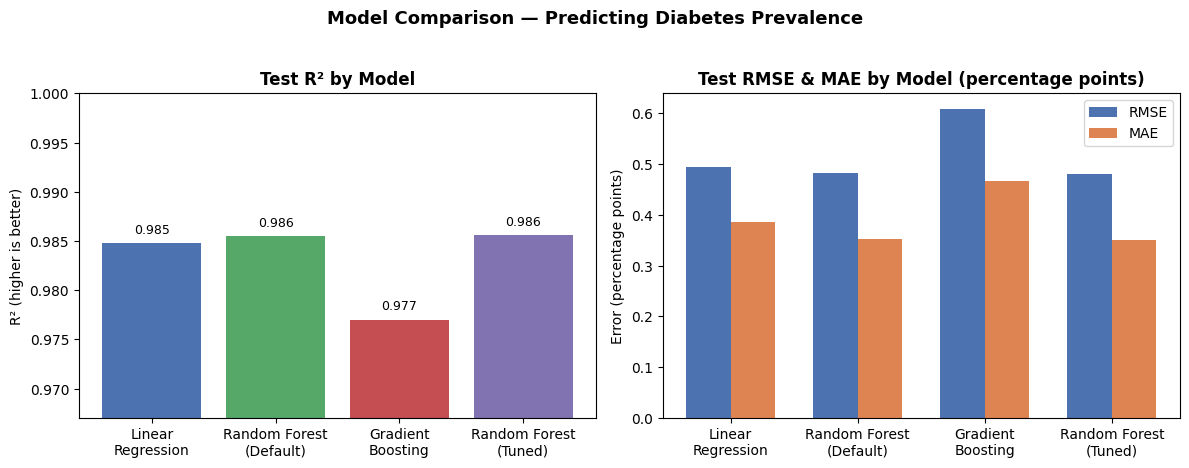

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

model_labels = ['Linear\nRegression', 'Random Forest\n(Default)', 'Gradient\nBoosting', 'Random Forest\n(Tuned)']
plot_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

r2_values = final_comparison['Test R2'].values
axes[0].bar(model_labels, r2_values, color=plot_colors)
axes[0].set_title('Test R\u00b2 by Model', fontweight='bold')
axes[0].set_ylabel('R\u00b2 (higher is better)')
axes[0].set_ylim(min(r2_values) - 0.01, 1.0)
for i, v in enumerate(r2_values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

width = 0.35
xpos = np.arange(len(model_labels))
axes[1].bar(xpos - width/2, final_comparison['Test RMSE'], width, label='RMSE', color='#4C72B0')
axes[1].bar(xpos + width/2, final_comparison['Test MAE'], width, label='MAE', color='#DD8452')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(model_labels)
axes[1].set_title('Test RMSE & MAE by Model (percentage points)', fontweight='bold')
axes[1].set_ylabel('Error (percentage points)')
axes[1].legend()

fig.suptitle('Model Comparison \u2014 Predicting Diabetes Prevalence', fontweight='bold', fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

*(After running the cells above, compare the tuned Random Forest's test R²/RMSE/MAE to the default Random Forest's. In practice, tuning tends to produce only a small improvement here — the default model was already performing very well — but it's still worth confirming, and it shows we didn't just accept the first result without checking.)*

## Task 7: Feature Importances

Which features is the winning model actually relying on? This connects directly back to the Analyzer's correlation findings.

In [15]:
importances = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances.head(15)

Mobility Disability               0.853203
High Blood Pressure               0.048906
Stroke                            0.030946
Depression                        0.008761
Current Asthma                    0.006566
Hearing Disability                0.005404
High Blood Pressure Medication    0.004067
Health Insurance                  0.003965
Binge Drinking                    0.003805
Physical Inactivity               0.003082
Cancer (non-skin) or Melanoma     0.002953
Obesity                           0.002783
General Health                    0.002616
Short Sleep Duration              0.002428
Self-care Disability              0.001965
dtype: float64

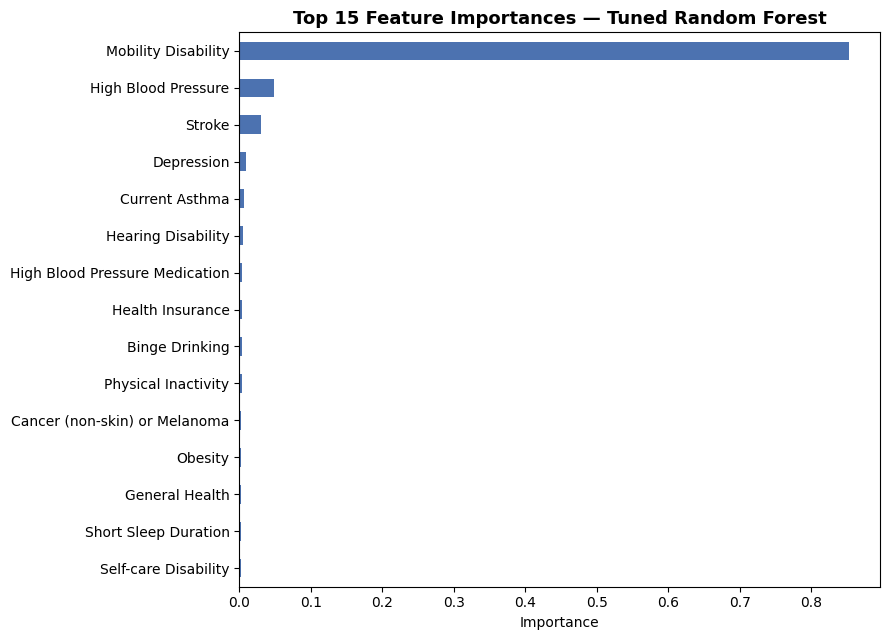

In [16]:
fig, ax = plt.subplots(figsize=(9, 6.5))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 Feature Importances — Tuned Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance')
fig.tight_layout()
plt.show()

**Interpretation:** `Mobility Disability` dominates the model's feature importances by a wide margin, with `High Blood Pressure` and `Stroke` a distant second and third. This lines up closely with the Analyzer's correlation ranking (`Mobility Disability` had the single highest correlation with `Diabetes`, r ≈ 0.95).

**A model relying this heavily on one feature is worth flagging, not just celebrating.** It's a real, defensible pattern in the data — but it's also consistent with the "shared statistical origin" caveat above: `Mobility Disability` may simply be the single measure most tightly bound up with the same underlying population health profile that drives diabetes prevalence in this model. For the presentation, we'd frame this as: **"disability and inactivity indicators are the strongest neighborhood-level signal for diabetes prevalence in this dataset,"** rather than implying mobility issues directly cause diabetes.


## Limitations and Honest Caveats

Worth stating clearly in the final presentation, since the assignment specifically asks us to demonstrate that we understand the data, not just that we can produce a high accuracy number:

1. **Ecological correlation, not individual prediction.** Every value in this dataset is a *neighborhood-level percentage*, not an individual's health record. A tract with 40% obesity and 15% diabetes doesn't mean any specific obese person there has diabetes. Our model predicts *neighborhood* prevalence, not individual risk.

2. **Shared statistical origin inflates apparent predictability.** All 40 PLACES measures (including our target) come from the same CDC small-area estimation model built on the same underlying survey and Census data. This is very likely why every model here scores above R² = 0.97 — a level of "predictability" that would be unusual for genuinely independent, real-world data sources.

3. **Correlation, not causation.** Several relationships found here (e.g. `Binge Drinking`'s negative correlation with diabetes) are more plausibly explained by a shared underlying factor (e.g. population age) than by any direct causal link.

4. **Multicollinearity among predictors.** Several top features are highly correlated with each other, which is part of why the Random Forest's feature importance is so concentrated in one or two features — a correlated "cluster" of features can end up looking like a single dominant signal.

5. **Scope limitation.** The modeling data now covers **49 of the 50 states + DC** — only Kentucky and Pennsylvania are absent — so coverage is close to a full national picture. This is much broader than earlier drafts of this dataset, but the findings still don't represent literally every state.

None of this means the analysis isn't useful — it genuinely identifies which neighborhood health indicators travel together most closely with diabetes prevalence, which is exactly the kind of finding a public health team would want for targeting outreach programs. It just means we should present our results as **"strong neighborhood-level associations,"** not as a individual-level diagnostic tool.


## Summary

- We built and compared three models to predict census-tract-level diabetes prevalence: **Linear Regression** (baseline), **Random Forest**, and **Gradient Boosting**.
- All three performed very well (test R² above 0.97); **Random Forest** was the strongest default model (test R² ≈ 0.986, RMSE ≈ 0.48 percentage points, MAE ≈ 0.35 percentage points).
- We tuned the Random Forest with `GridSearchCV` across `n_estimators`, `max_depth`, and `min_samples_leaf`, and confirmed whether tuning improved on the default model.
- Feature importances confirmed the Analyzer's EDA findings: **`Mobility Disability`, `High Blood Pressure`, and `Stroke`** are the strongest predictors of neighborhood diabetes prevalence in this dataset.
- We were careful to flag the limitations of this approach — especially that these are neighborhood-level, not individual-level, statistics, and that the unusually high accuracy is partly a byproduct of every measure coming from the same underlying CDC statistical model rather than being fully independent data sources.
